# XGBoost From Scratch — A Beginner's Guide

**XGBoost (Extreme Gradient Boosting)** is an ensemble method that builds decision trees **one at a time, sequentially**. Each new tree tries to correct the mistakes of all the previous trees combined.

This is very different from **Random Forest**, where many trees are built *independently* (in parallel) and simply vote on the final answer. In boosting, every tree is built **on purpose** to fix what the current ensemble is still getting wrong.

### The core idea of "boosting"
1. Start with a simple guess (e.g. predict the same value for everyone).
2. Look at how wrong that guess is for each sample (the *error*).
3. Train a small tree whose job is only to predict that error.
4. Add the new tree's prediction (scaled down a bit) to the running total.
5. Repeat — each round the ensemble gets a little better.

The animation below shows this happening on our actual diabetes dataset: as more small trees are added one after another, the training loss shrinks.

![XGBoost Animation](images/xgboost.gif)

In this notebook we will build a **simplified version of XGBoost completely from scratch**, using only NumPy, pandas, and matplotlib. We won't implement every optimization from the original paper (no column subsampling, no tree pruning, no parallelization) — just the core idea, so it's easy to follow.

## 2. Load and Explore the Data

Let's first look at the real structure of the dataset before assuming anything about it.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("datasets/diabetes.csv")
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


**About this dataset:** it contains **8 numeric input features** (e.g. `Glucose`, `BloodPressure`, `BMI`, `Age`, ...) describing patient health measurements, and one target column, **`Outcome`**, which is **binary**: `1` means the patient has diabetes, `0` means they don't. So this is a **binary classification** problem, and there are no missing values to worry about.

## 3. Select Features and Target

We'll use every column except `Outcome` as input features, and `Outcome` as the target.

Note: unlike linear models, **tree-based models (like XGBoost) don't need feature scaling** — a tree only asks "is this value above or below a threshold?", so the scale of each feature doesn't matter.

In [3]:
feature_names = df.drop(columns=["Outcome"]).columns.tolist()

X = df.drop(columns=["Outcome"]).values.astype(float)
y = df["Outcome"].values.astype(float)

print("Features:", feature_names)
print("X shape:", X.shape, " y shape:", y.shape)

Features: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']
X shape: (768, 8)  y shape: (768,)


## 4. Train/Test Split (Manual)

We shuffle the row indices ourselves with NumPy and slice out an 80/20 train/test split — no `sklearn.model_selection` involved.

In [4]:
np.random.seed(42)

n_samples = X.shape[0]
shuffled_idx = np.random.permutation(n_samples)

split_point = int(0.8 * n_samples)
train_idx, test_idx = shuffled_idx[:split_point], shuffled_idx[split_point:]

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

print("Train size:", X_train.shape[0], " Test size:", X_test.shape[0])

Train size: 614  Test size: 154


## 5. The Idea Behind XGBoost (Simplified)

- **Starting point:** the model begins with the same simple prediction for everyone (we use `0`, before turning it into a probability).
- **Residuals as the next target:** at every round, we check how wrong the *current combined model* is for each sample. That error becomes what the next small tree tries to predict.
- **Gradient & Hessian (intuitively):**
  - **Gradient** = *how wrong* the model currently is for a sample (`predicted probability − actual label`).
  - **Hessian** = *how confident/sensitive* that error is (`probability × (1 − probability)`).
- **Leaf output (simplified formula):** each leaf of a small tree predicts

  $$\text{leaf value} = \frac{-\sum \text{gradients in leaf}}{\sum \text{hessians in leaf} + \lambda}$$

  where `lambda` is a small regularization term that stops a leaf from overreacting when it only contains a few samples.
- **Shrinkage (learning rate):** we scale down every new tree's contribution by a small learning rate before adding it in, so no single tree dominates and training improves gradually and stays stable.
- **Final prediction:** add up the starting value plus the (scaled) output of every tree, then squash the result with the **Sigmoid** function to get a probability between 0 and 1.

## 6. Small Regression Tree (The Weak Learner)

This is the building block used inside the boosting loop. Instead of predicting a class, each leaf predicts a value computed from the gradients and hessians of the samples that land in it.

A split is considered "good" if it increases the **gain** — the amount by which separating high-error samples from low-error samples reduces the overall loss.

In [5]:
class TreeNode:
    '''A single node in our small regression tree.'''
    def __init__(self):
        self.is_leaf = True
        self.value = 0.0       # prediction stored at a leaf
        self.feature = None    # feature index used to split
        self.threshold = None  # split threshold
        self.left = None
        self.right = None


def leaf_value(g, h, lam):
    '''Optimal leaf output, from the gradients/hessians of samples in that leaf.'''
    return -g.sum() / (h.sum() + lam)


def best_split(X, g, h, lam, min_leaf):
    '''Try candidate thresholds on every feature and keep the split with highest gain.'''
    n_samples, n_features = X.shape
    G, H = g.sum(), h.sum()

    best_gain, best_feature, best_threshold = 1e-6, None, None

    for f in range(n_features):
        thresholds = np.unique(X[:, f])
        thresholds = (thresholds[:-1] + thresholds[1:]) / 2  # midpoints between values

        for thr in thresholds:
            left_mask = X[:, f] <= thr
            n_left, n_right = left_mask.sum(), n_samples - left_mask.sum()
            if n_left < min_leaf or n_right < min_leaf:
                continue  # keep leaves from being too small (stabilizes training)

            GL, HL = g[left_mask].sum(), h[left_mask].sum()
            GR, HR = G - GL, H - HL

            # Simplified XGBoost gain formula
            gain = 0.5 * ((GL**2) / (HL + lam) + (GR**2) / (HR + lam) - (G**2) / (H + lam))

            if gain > best_gain:
                best_gain, best_feature, best_threshold = gain, f, thr

    return best_feature, best_threshold


def build_tree(X, g, h, depth, max_depth, lam, min_leaf):
    '''Recursively grow a shallow regression tree.'''
    node = TreeNode()

    if depth >= max_depth or len(X) < 2 * min_leaf:
        node.value = leaf_value(g, h, lam)
        return node

    feature, threshold = best_split(X, g, h, lam, min_leaf)

    if feature is None:  # no split improved the gain enough -> stop here
        node.value = leaf_value(g, h, lam)
        return node

    node.is_leaf = False
    node.feature, node.threshold = feature, threshold

    left_mask = X[:, feature] <= threshold
    node.left = build_tree(X[left_mask], g[left_mask], h[left_mask], depth + 1, max_depth, lam, min_leaf)
    node.right = build_tree(X[~left_mask], g[~left_mask], h[~left_mask], depth + 1, max_depth, lam, min_leaf)
    return node


def predict_tree(node, X):
    '''Walk every sample down the tree to its leaf value.'''
    preds = np.empty(len(X))
    for i, x in enumerate(X):
        n = node
        while not n.is_leaf:
            n = n.left if x[n.feature] <= n.threshold else n.right
        preds[i] = n.value
    return preds

## 7. XGBoost From Scratch (The Boosting Loop)

Now we combine many of these small trees, one after another, where each new tree is trained on the **gradients and hessians** of the current ensemble's errors.

In [6]:
def sigmoid(x):
    x = np.clip(x, -30, 30)  # avoid overflow
    return 1 / (1 + np.exp(-x))


def train_xgboost(X, y, n_trees=30, learning_rate=0.15, max_depth=2, lam=5.0, min_leaf=10):
    '''Train a simplified XGBoost classifier from scratch.'''
    raw_pred = np.zeros(len(X))   # running prediction, before sigmoid
    trees = []
    losses = []

    for t in range(n_trees):
        # 1) Turn current raw predictions into probabilities
        p = sigmoid(raw_pred)

        # 2) Gradient = how wrong, Hessian = how sure
        g = p - y
        h = p * (1 - p) + 1e-6

        # 3) Train one small tree to fit these gradients/hessians
        tree = build_tree(X, g, h, depth=0, max_depth=max_depth, lam=lam, min_leaf=min_leaf)

        # 4) Update running predictions, scaled by the learning rate (shrinkage)
        raw_pred += learning_rate * predict_tree(tree, X)

        # 5) Store the tree so we can reuse it at prediction time
        trees.append(tree)

        # Track training loss (log loss) for this round
        eps = 1e-15
        p_final = np.clip(sigmoid(raw_pred), eps, 1 - eps)
        loss = -np.mean(y * np.log(p_final) + (1 - y) * np.log(1 - p_final))
        losses.append(loss)

    return trees, losses

## 8. Training the Model

Each new tree focuses on the samples the current ensemble is still getting wrong, so the training loss should generally go down round by round.

In [7]:
N_TREES = 30
LEARNING_RATE = 0.15
MAX_DEPTH = 2
LAMBDA = 5.0
MIN_LEAF = 10

trees, train_losses = train_xgboost(
    X_train, y_train,
    n_trees=N_TREES,
    learning_rate=LEARNING_RATE,
    max_depth=MAX_DEPTH,
    lam=LAMBDA,
    min_leaf=MIN_LEAF,
)

print(f"Loss after round 1:  {train_losses[0]:.4f}")
print(f"Loss after round {N_TREES}: {train_losses[-1]:.4f}")

Loss after round 1:  0.6493
Loss after round 30: 0.4152


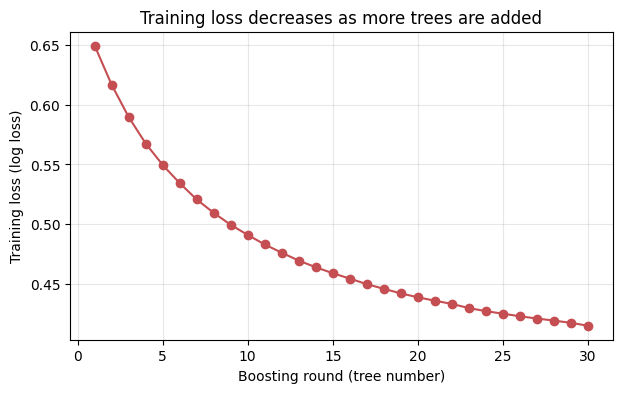

In [8]:
plt.figure(figsize=(7, 4))
plt.plot(range(1, N_TREES + 1), train_losses, marker="o", color="#C44E52")
plt.xlabel("Boosting round (tree number)")
plt.ylabel("Training loss (log loss)")
plt.title("Training loss decreases as more trees are added")
plt.grid(alpha=0.3)
plt.show()

## 9. Making Predictions

To predict on new data, we sum the starting value plus the scaled output of **every** trained tree, apply Sigmoid, then threshold at 0.5 to get a class.

In [9]:
def predict_proba(X, trees, learning_rate):
    raw_pred = np.zeros(len(X))
    for tree in trees:
        raw_pred += learning_rate * predict_tree(tree, X)
    return sigmoid(raw_pred)


test_prob = predict_proba(X_test, trees, LEARNING_RATE)
test_pred = (test_prob >= 0.5).astype(int)

test_prob[:10], test_pred[:10]

(array([0.05860821, 0.22299849, 0.59706424, 0.66960849, 0.61428272,
        0.61218819, 0.32487584, 0.20000187, 0.21222207, 0.36993633]),
 array([0, 0, 1, 1, 1, 1, 0, 0, 0, 0]))

## 10. Model Evaluation (Manual)

We compute accuracy, and a simple confusion matrix, by hand — no `sklearn.metrics`.

In [10]:
y_test_int = y_test.astype(int)

accuracy = np.mean(test_pred == y_test_int)
print(f"Test Accuracy: {accuracy:.2%}")

TP = np.sum((test_pred == 1) & (y_test_int == 1))
TN = np.sum((test_pred == 0) & (y_test_int == 0))
FP = np.sum((test_pred == 1) & (y_test_int == 0))
FN = np.sum((test_pred == 0) & (y_test_int == 1))

precision = TP / (TP + FP) if (TP + FP) > 0 else 0
recall = TP / (TP + FN) if (TP + FN) > 0 else 0
f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

print(f"Confusion Matrix -> TP: {TP}  TN: {TN}  FP: {FP}  FN: {FN}")
print(f"Precision: {precision:.2f}  Recall: {recall:.2f}  F1-score: {f1:.2f}")

Test Accuracy: 71.43%
Confusion Matrix -> TP: 29  TN: 81  FP: 15  FN: 29
Precision: 0.66  Recall: 0.50  F1-score: 0.57


## 11. Visualization

We already saw the loss curve above. Now let's compare the predicted probabilities for **correctly** vs **incorrectly** classified test samples — a well-trained model should be much more confident when it's right.

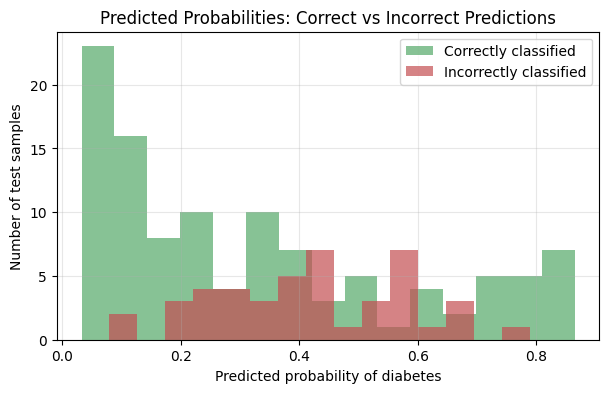

In [11]:
correct_mask = (test_pred == y_test_int)

plt.figure(figsize=(7, 4))
plt.hist(test_prob[correct_mask], bins=15, alpha=0.7, label="Correctly classified", color="#55A868")
plt.hist(test_prob[~correct_mask], bins=15, alpha=0.7, label="Incorrectly classified", color="#C44E52")
plt.xlabel("Predicted probability of diabetes")
plt.ylabel("Number of test samples")
plt.title("Predicted Probabilities: Correct vs Incorrect Predictions")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 12. Conclusion

- **XGBoost** builds decision trees **sequentially**, where each tree is trained specifically to correct the errors of the trees before it.
- This is the key difference from **bagging methods like Random Forest**, which build many trees *independently* and combine them by voting/averaging.
- The **gradient** tells each new tree *how wrong* the current ensemble is for every sample, and the **hessian** tells it *how confident* that error is — together they guide where and how the next tree should correct the model.
- **Shrinkage** (the learning rate) scales down every tree's contribution, so the ensemble improves gradually and training stays stable instead of overreacting to any single tree.
- The **final prediction** is simply the starting value plus the sum of every tree's (scaled) contribution, passed through the **Sigmoid** function to produce a probability.

That's the essence of gradient boosting — simple pieces, combined sequentially, each one fixing what came before.